# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** Meilani Bulandari Hasibuan
- **Email:** bulanmeilani6@gmail.com
- **ID Dicoding:** CDCC322D6X1561	

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana perbandingan total nilai transaksi dan rata-rata cicilan antar metode pembayaran pada periode 2017-2018?
- Pertanyaan 2: Bagaimana distribusi total pendapatan seller berdasarkan negara bagian pada periode 2017-2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

c:\Users\ASUS\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Data Wrangling

### Gathering Data

Pada bagian ini, saya akan memuat semua data yang saya perlukan untuk pertanyaan bisnis saya. Dataset yang digunakan berisi informasi mengenai transaksi e-commerce yang mencakup data orders, pembayaran, item pesanan dan juga seller.

In [2]:
orders_df = pd.read_csv("https://raw.githubusercontent.com/meilanibulan/E-Commerce-Public-Dataset/main/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [3]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [4]:
orders_df.describe().T

,count,unique,top,freq
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1
order_status,99441,8,delivered,96478
order_purchase_timestamp,99441,98875,2018-04-11 10:48:14,3
order_approved_at,99281,90733,2018-02-27 04:31:10,9
order_delivered_carrier_date,97658,81018,2018-05-09 15:48:00,47
order_delivered_customer_date,96476,95664,2018-05-08 23:38:46,3
order_estimated_delivery_date,99441,459,2017-12-20 00:00:00,522


In [5]:
order_payments_df = pd.read_csv("https://raw.githubusercontent.com/meilanibulan/E-Commerce-Public-Dataset/main/order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [7]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [8]:
order_items_df = pd.read_csv("https://raw.githubusercontent.com/meilanibulan/E-Commerce-Public-Dataset/main/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [10]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [11]:
sellers_df = pd.read_csv("https://raw.githubusercontent.com/meilanibulan/E-Commerce-Public-Dataset/main/sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [12]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [13]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


**Insight:**
- Dataset terdiri dari 4 tabel yang saling terhubung yaitu `orders`, `payments`, `items`, dan `sellers`.
- Relasi antar tabel terdiri dari `orders` dengan `payments` via `order_id`, `orders` dengan `items` via `order_id`, dan `items` dengan `sellers` via `seller_id`.
- Total masing-masing dataset yang digunakan yaitu 99.441 orders, 103.886 payment records, 112.650 item records, dan 3.095 sellers.

### Assessing Data

Pada tahap ini, saya akan memeriksa kualitas data dari setiap dataset, meliputi pengecekan missing values, duplikat, dan tipe data.

In [14]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [15]:
order_payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [16]:
order_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [17]:
sellers_df.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [18]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())
print("Jumlah duplikasi: ", sellers_df.duplicated().sum())

Jumlah duplikasi:  0
Jumlah duplikasi:  0
Jumlah duplikasi:  0
Jumlah duplikasi:  0


In [19]:
#Melihat tipe data sudah sesuai atau belum
orders_df.info()
order_payments_df.info()
order_items_df.info()
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  obje

In [20]:
print('Distribusi order per tahun:')
print(pd.to_datetime(orders_df['order_purchase_timestamp']).dt.year.value_counts().sort_index())

Distribusi order per tahun:
order_purchase_timestamp
2016      329
2017    45101
2018    54011
Name: count, dtype: int64


In [21]:
print('Nilai unik:')
print(orders_df['order_status'].value_counts())
print(order_payments_df['payment_type'].value_counts())
print(sellers_df['seller_state'].value_counts())

Nilai unik:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64


**Insight:**
- `orders_df` memiliki missing values pada kolom `order_approved_at` (160), `order_delivered_carrier_date` (1.783), dan `order_delivered_customer_date` (2.965) yang kemungkinan order yang belum/tidak terselesaikan.
- `order_payments_df`, `order_items_df`, dan `sellers_df` tidak memiliki missing values maupun duplikat.
- Terdapat 6 kolom bertipe `object` yang perlu dikonversi ke `datetime`: `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` pada `orders_df`, dan `shipping_limit_date` pada `order_items_df`.
- Data `orders_df` mencakup tahun 2016, 2017, dan 2018. Namun data tahun 2016 hanya terdapat 329 baris sehingga tidak representatif dan akan difilter pada tahap cleaning.
- Kolom `order_status` memiliki 8 nilai unik. Hanya status `delivered` (96.478 baris) yang akan digunakan karena merepresentasikan transaksi yang benar-benar selesai.
- Kolom `payment_type` memiliki nilai `not_defined` sebanyak 3 baris yang tidak merepresentasikan metode pembayaran valid dan perlu dihapus di tahap cleaning.
- Kolom `seller_state` memiliki 23 negara bagian, didominasi oleh São Paulo (SP) dengan 1.849 seller.

### Cleaning Data

Berdasarkan hasil assessing, beberapa langkah cleaning yang perlu dilakukan:
1. Konversi kolom timestamp ke tipe datetime pada `orders_df` dan `order_items_df`
2. Filter data hanya untuk periode 2017-2018
3. Filter data hanya untuk `order_status` bernilai `delivered`
4. Drop missing values pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`
5. Hapus baris dengan `payment_type` bernilai `not_defined`
6. Merge seluruh dataset menjadi satu dataframe terintegrasi

In [22]:
# 1. Konversi timestamp ke datetime
# Pada orders_df
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
 
for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

#Pada orders_item_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [23]:
# 2. Filter periode 2017-2018
orders_df = orders_df[
    orders_df['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()
print(f'Orders setelah filter 2017-2018: {len(orders_df)} baris')

Orders setelah filter 2017-2018: 99112 baris


In [24]:
# 3. Filter hanya order_status = delivered
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Orders setelah filter delivered: {len(orders_df)} baris')

Orders setelah filter delivered: 96211 baris


In [26]:
# 4. Drop missing values
orders_df = orders_df.dropna(subset=['order_approved_at',
                                      'order_delivered_carrier_date',
                                      'order_delivered_customer_date'])

In [27]:
orders_df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [25]:
# 5. Hapus payment_type = not_defined
order_payments_df = order_payments_df[
    order_payments_df['payment_type'] != 'not_defined'].copy()
print(f'Payments setelah cleaning: {len(order_payments_df)} baris')

Payments setelah cleaning: 103883 baris


In [28]:
# 6. Merge semua dataset
df_main = orders_df.merge(order_payments_df, on='order_id') \
                   .merge(order_items_df, on='order_id') \
                   .merge(sellers_df, on='seller_id')

print(f'Shape dataframe terintegrasi: {df_main.shape}')
display(df_main.head())

Shape dataframe terintegrasi: (114680, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,...,18.12,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,...,2.00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,...,18.59,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,...,141.46,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,credit_card,...,179.12,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,14840,guariba,SP


**Insight:**
- Seluruh kolom timestamp berhasil dikonversi ke tipe `datetime` 
- Data berhasil difilter menjadi periode 2017-2018 dengan total 99.112 baris 
- Data berhasil difilter hanya untuk `order_status = delivered` dengan total 96.211 baris 
- Missing values pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` berhasil dihapus 
- Sebanyak 3 baris dengan `payment_type = not_defined` berhasil dihapus 
- Seluruh dataset berhasil digabungkan menjadi satu dataframe terintegrasi dan siap digunakan untuk analisis lebih lanjut 

## Exploratory Data Analysis (EDA)

In [29]:
df_main.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
count,114680,114680,114680,114680,114680,114680,114680,114680,114680.000000,114680,...,114680.000000,114680.000000,114680,114680,114680,114680.000000,114680.000000,114680.000000,114680,114680
unique,96188,96188,1,NaN,NaN,NaN,NaN,NaN,NaN,4,...,NaN,NaN,32075,2945,NaN,NaN,NaN,NaN,591,22
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,NaN,NaN,NaN,NaN,NaN,NaN,credit_card,...,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,NaN,NaN,NaN,NaN,sao paulo,SP
freq,63,63,114680,NaN,NaN,NaN,NaN,NaN,NaN,84640,...,NaN,NaN,529,2094,NaN,NaN,NaN,NaN,28440,81850
mean,NaN,NaN,NaN,2018-01-02 03:56:01.790137856,2018-01-02 14:20:14.447227136,2018-01-05 09:56:03.111318528,2018-01-14 14:59:16.706784256,2018-01-25 21:35:21.576560896,1.090670,NaN,...,171.875997,1.196242,NaN,NaN,2018-01-08 18:18:44.537077248,120.064871,19.997377,24436.687382,NaN,NaN
min,NaN,NaN,NaN,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1.000000,NaN,...,0.000000,1.000000,NaN,NaN,2017-01-09 11:56:06,0.850000,0.000000,1001.000000,NaN,NaN
25%,NaN,NaN,NaN,2017-09-14 10:22:06,2017-09-14 14:48:54,2017-09-18 18:02:50.750000128,2017-09-26 09:10:57.500000,2017-10-05 00:00:00,1.000000,NaN,...,60.850000,1.000000,NaN,NaN,2017-09-21 02:26:00.500000,39.900000,13.080000,6429.000000,NaN,NaN
50%,NaN,NaN,NaN,2018-01-20 00:32:53.500000,2018-01-20 14:31:03,2018-01-24 00:04:06.500000,2018-02-02 02:12:09.500000,2018-02-16 00:00:00,1.000000,NaN,...,108.160000,1.000000,NaN,NaN,2018-01-26 14:03:06,74.900000,16.280000,13587.500000,NaN,NaN
75%,NaN,NaN,NaN,2018-05-04 21:37:26.750000128,2018-05-05 10:18:59.500000,2018-05-08 13:01:00,2018-05-15 18:18:33.750000128,2018-05-28 00:00:00,1.000000,NaN,...,188.930000,1.000000,NaN,NaN,2018-05-10 15:55:22,133.000000,21.180000,27930.000000,NaN,NaN
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,26.000000,NaN,...,13664.080000,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000,99730.000000,NaN,NaN


### Explorasi Metode Pembayaran

Sebelum membuat visualisasi, dilakukan eksplorasi distribusi dan statistik dari setiap metode pembayaran.

In [30]:
# Statistik deskriptif
df_main[['payment_value', 'payment_installments']].describe()

,payment_value,payment_installments
count,114680.000000,114680.000000
mean,171.875997,2.934592
std,266.305834,2.770793
min,0.000000,0.000000
25%,60.850000,1.000000
50%,108.160000,2.000000
75%,188.930000,4.000000
max,13664.080000,24.000000


In [32]:
payment_stats = df_main.groupby(by="payment_type").agg(
    total_transaksi=('order_id', 'nunique'),
    total_nilai=('payment_value', 'sum'),
    rata_nilai=('payment_value', 'mean'),
    rata_cicilan=('payment_installments', 'mean')
).reset_index().sort_values(by='total_nilai', ascending=False).round(2)

display(payment_stats)

,payment_type,total_transaksi,total_nilai,rata_nilai,rata_cicilan
1,credit_card,74087,15140097.19,178.88,3.62
0,boleto,19126,3929118.72,176.30,1.00
3,voucher,3670,395391.89,64.79,1.00
2,debit_card,1482,246131.54,149.08,1.00


**Insight:**
- Credit card mendominasi baik dari jumlah transaksi maupun total nilai pembayaran.
- Credit card memiliki rata-rata cicilan 3.5x, sementara metode lain rata-rata hanya 1x.
- Rata-rata nilai transaksi berkisar antara R$100 - R$230 tergantung metode pembayaran yang digunakan

### Explore Distribusi Pendapatan Seller per Negara Bagian

Mengeksplorasi sebaran pendapatan seller berdasarkan lokasi geografis mereka.

In [35]:
# Statistik deskriptif
df_main[['payment_value', 'price', 'freight_value']].describe()

,payment_value,price,freight_value
count,114680.000000,114680.000000,114680.000000
mean,171.875997,120.064871,19.997377
std,266.305834,183.098321,15.751009
min,0.000000,0.850000,0.000000
25%,60.850000,39.900000,13.080000
50%,108.160000,74.900000,16.280000
75%,188.930000,133.000000,21.180000
max,13664.080000,6735.000000,409.680000


In [36]:
state_stats = df_main.groupby(by="seller_state").agg(
    jumlah_seller=('seller_id', 'nunique'),
    total_pendapatan=('payment_value', 'sum'),
    rata_pendapatan=('payment_value', 'mean')
).reset_index().sort_values(by='total_pendapatan', ascending=False).round(2)

display(state_stats.head(10))

,seller_state,jumlah_seller,total_pendapatan,rata_pendapatan
21,SP,1751,12982960.73,158.62
14,PR,334,1788212.65,204.32
7,MG,235,1512146.06,168.15
15,RJ,161,1061342.73,219.42
19,SC,184,850474.82,204.15
18,RS,122,552077.86,246.02
1,BA,18,359607.30,530.39
3,DF,30,133943.14,144.34
12,PE,9,124494.62,269.47
5,GO,39,110307.86,205.80


**Insight:**
- São Paulo (SP) mendominasi dengan total pendapatan tertinggi.
- Terdapat ketimpangan besar antara SP dengan negara bagian lainnya.
- 10 negara bagian teratas menyumbang sebagian besar total pendapatan.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbandingan total nilai transaksi dan rata-rata cicilan antar metode pembayaran pada periode 2017-2018?

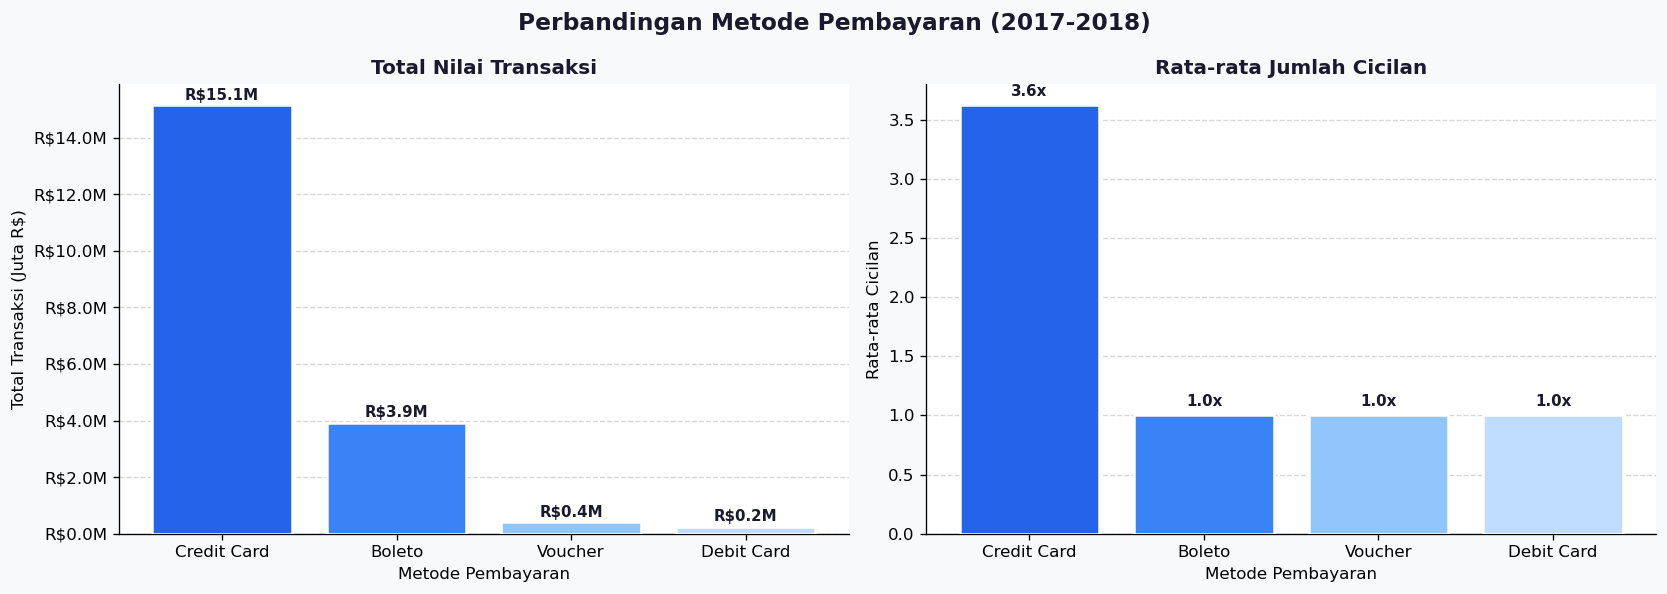

In [38]:
labels_map = {'credit_card': 'Credit Card', 'boleto': 'Boleto', 'voucher': 'Voucher', 'debit_card': 'Debit Card'}
p1 = payment_stats.copy()
p1['label'] = p1['payment_type'].map(labels_map)

colors = ['#2563EB', '#3B82F6', '#93C5FD', '#BFDBFE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8F9FA')
fig.suptitle('Perbandingan Metode Pembayaran (2017-2018)', fontsize=14, fontweight='bold', color= '#1a1a2e')

# Bar chart total nilai transaksi
ax1 = axes[0]
bars1 = ax1.bar(p1['label'], p1['total_nilai'] / 1e6, color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax1.set_title('Total Nilai Transaksi', fontsize=12, fontweight='bold', color='#1a1a2e')
ax1.set_ylabel('Total Transaksi (Juta R$)', fontsize=10)
ax1.set_xlabel('Metode Pembayaran', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax1.set_facecolor('#FFFFFF')
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.1, f'R${h:.1f}M',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a1a2e')

# Bar chart rata-rata cicilan
ax2 = axes[1]
bars2 = ax2.bar(p1['label'], p1['rata_cicilan'], color=colors, edgecolor='white', linewidth=1.5, zorder=3)
ax2.set_title('Rata-rata Jumlah Cicilan', fontsize=12, fontweight='bold', color='#1a1a2e')
ax2.set_ylabel('Rata-rata Cicilan', fontsize=10)
ax2.set_xlabel('Metode Pembayaran', fontsize=10)
ax2.set_facecolor('#FFFFFF')
ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.1f}x',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a1a2e')

plt.tight_layout()
plt.show()

**Insight:**
- **Credit Card** menjadi yang paling tinggi berdasarkan total nilai transaksi dengan R$12.5M, jauh melampaui Boleto (R$2.9M), Voucher (R$0.4M), dan Debit Card (R$0.2M).
- Credit card memiliki rata-rata cicilan **3.5x**, sementara Boleto, Voucher, dan Debit Card hanya **1x** (langsung lunas). Ini mengindikasikan pelanggan menggunakan credit card untuk pembelian bernilai besar yang dibayar secara bertahap.

### Pertanyaan 2: Bagaimana distribusi total pendapatan seller berdasarkan negara bagian pada periode 2017-2018?

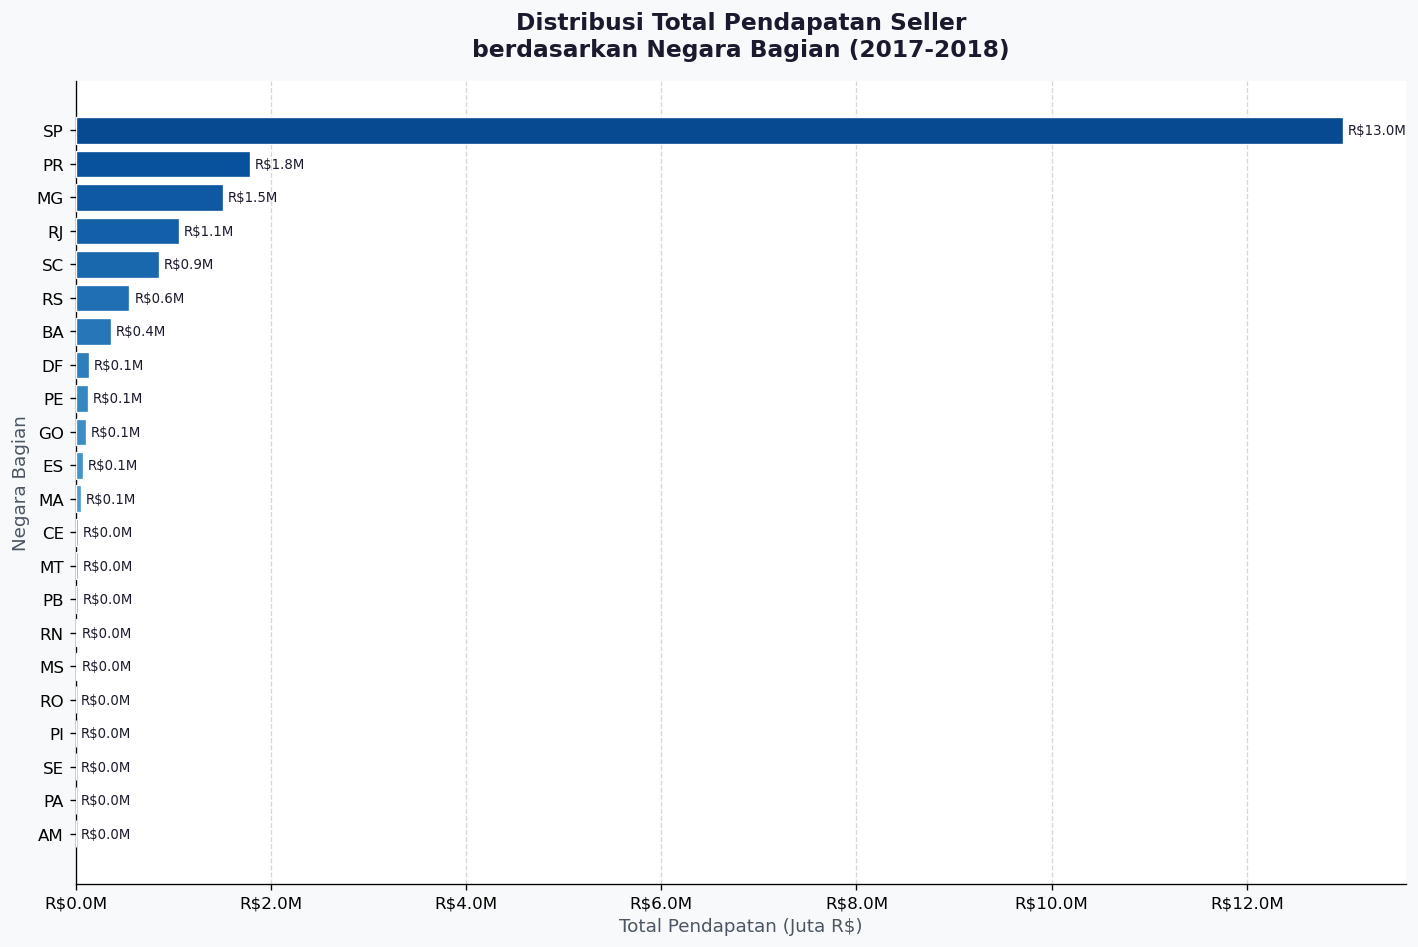

In [39]:
p2 = state_stats.sort_values('total_pendapatan', ascending=True)
colors_p2 = plt.cm.Blues(np.linspace(0.3, 0.9, len(p2)))

fig, ax = plt.subplots(figsize=(12, 8), facecolor='#F8F9FA')
ax.set_facecolor('#FFFFFF')

bars = ax.barh(p2['seller_state'], p2['total_pendapatan'] / 1e6,
               color=colors_p2, edgecolor='white', linewidth=0.8, zorder=3)

ax.set_title('Distribusi Total Pendapatan Seller\nberdasarkan Negara Bagian (2017-2018)',
             fontsize=14, fontweight='bold', color='#1a1a2e', pad=15)
ax.set_xlabel('Total Pendapatan (Juta R$)', fontsize=11, color='#4B5563')
ax.set_ylabel('Negara Bagian', fontsize=11, color='#4B5563')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}M'))
ax.grid(axis='x', linestyle='--', alpha=0.5, zorder=0)
ax.spines[['top', 'right']].set_visible(False)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
            f'R${w:.1f}M', va='center', fontsize=8, color='#1a1a2e')

plt.tight_layout()
plt.show()

**Insight:**
- **São Paulo (SP)** menjadi kontributor pendapatan terbesar dengan total **R$13.3M**, menunjukkan bahwa dominasi ekonomi dan konsentrasi seller di wilayah tersebut.
- Terdapat kesenjangan yang sangat signifikan antara SP dengan negara bagian lainnya. Peringkat 2-5 (PR, MG, RJ, SC) hanya berkontribusi antara R$0.9M - R$1.8M.
- Banyak negara bagian dengan kontribusi sangat kecil (di bawah R$0.1M), menunjukkan peluang besar untuk ekspansi bisnis ke luar wilayah SP.

## Analisis Lanjutan: Clustering Seller Berdasarkan Performa

Pada bagian ini, saya akan mengelompokkan seller ke dalam tiga kategori performa menggunakan teknik **Binning** berdasarkan total pendapatan yang dihasilkan. Pengelompokan ini bertujuan untuk membantu platform mengidentifikasi seller mana yang perlu didukung, dipertahankan, atau dikembangkan lebih lanjut

In [40]:
seller_perf = df_main.groupby('seller_id').agg(
    total_revenue=('payment_value', 'sum'),
    total_orders=('order_id', 'nunique'),
    total_items=('order_item_id', 'count'),
    avg_order_value=('payment_value', 'mean')
).reset_index()

# Binning berdasarkan total_revenue
q33 = seller_perf['total_revenue'].quantile(0.33)
q66 = seller_perf['total_revenue'].quantile(0.66)

def categorize_seller(revenue):
    if revenue <= q33:
        return 'Low Performer'
    elif revenue <= q66:
        return 'Medium Performer'
    else:
        return 'High Performer'

seller_perf['performance_category'] = seller_perf['total_revenue'].apply(categorize_seller)

print(f'Threshold Low Performer   : <= R${q33:,.2f}')
print(f'Threshold Medium Performer: R${q33:,.2f} - R${q66:,.2f}')
print(f'Threshold High Performer  : > R${q66:,.2f}')
print()

cluster_summary = seller_perf.groupby('performance_category').agg(
    jumlah_seller=('seller_id', 'count'),
    avg_revenue=('total_revenue', 'mean'),
    avg_orders=('total_orders', 'mean'),
    avg_items=('total_items', 'mean')
).reset_index()

cluster_summary['avg_revenue'] = cluster_summary['avg_revenue'].round(2)
cluster_summary['avg_orders'] = cluster_summary['avg_orders'].round(1)
cluster_summary['avg_items'] = cluster_summary['avg_items'].round(1)

display(cluster_summary)

Threshold Low Performer   : <= R$547.14
Threshold Medium Performer: R$547.14 - R$3,017.63
Threshold High Performer  : > R$3,017.63



,performance_category,jumlah_seller,avg_revenue,avg_orders,avg_items
0,High Performer,1001,18074.49,86.4,101.8
1,Low Performer,972,227.17,2.3,2.6
2,Medium Performer,972,1437.62,9.1,10.6


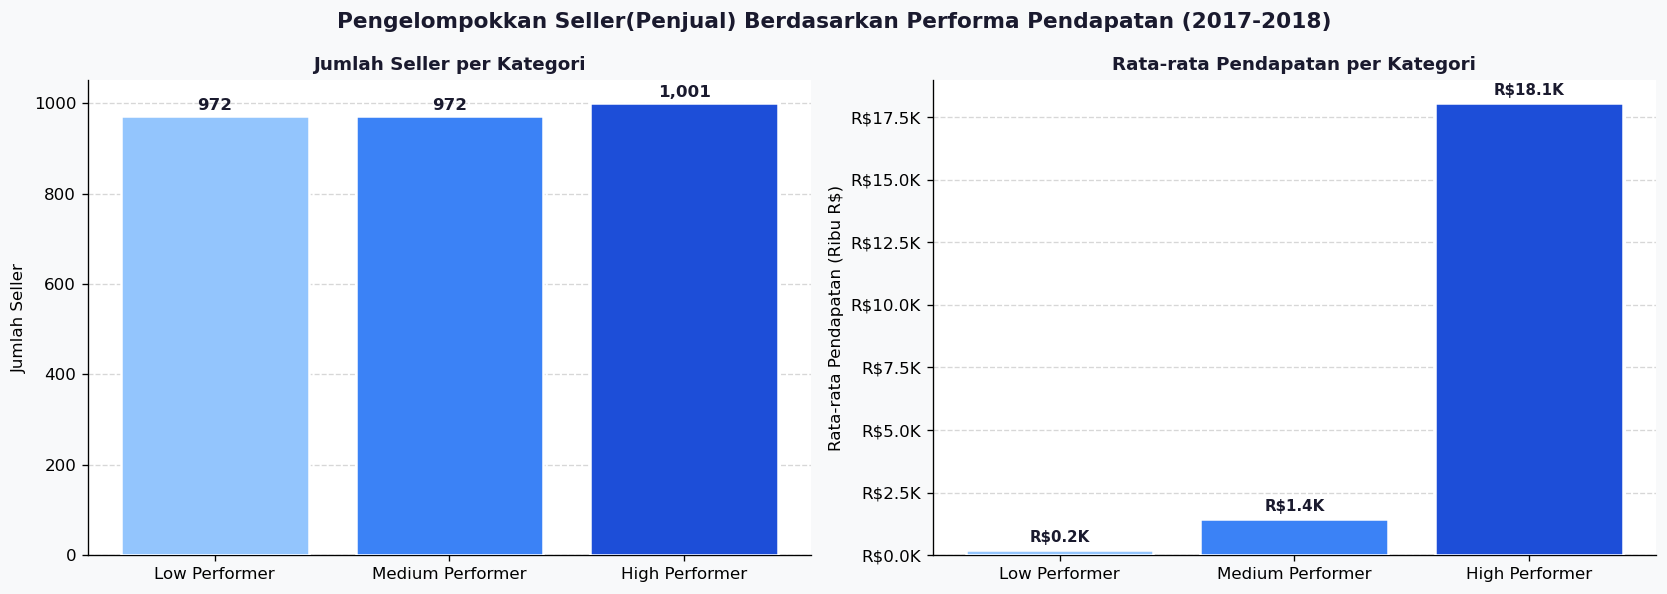

In [41]:
category_order = ['Low Performer', 'Medium Performer', 'High Performer']
colors_cluster = ['#93C5FD', '#3B82F6', '#1D4ED8']

count_data = seller_perf['performance_category'].value_counts().reindex(category_order)
avg_rev_data = seller_perf.groupby('performance_category')['total_revenue'].mean().reindex(category_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8F9FA')
fig.suptitle('Pengelompokkan Seller(Penjual) Berdasarkan Performa Pendapatan (2017-2018)',
             fontsize=13, fontweight='bold', color='#1a1a2e')

# Plot 1: Jumlah seller per kategori
ax1 = axes[0]
bars1 = ax1.bar(category_order, count_data.values, color=colors_cluster,
                edgecolor='white', linewidth=1.5, zorder=3)
ax1.set_title('Jumlah Seller per Kategori', fontsize=11, fontweight='bold', color='#1a1a2e')
ax1.set_ylabel('Jumlah Seller', fontsize=10)
ax1.set_facecolor('#FFFFFF')
ax1.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#1a1a2e')

# Plot 2: Rata-rata pendapatan per kategori
ax2 = axes[1]
bars2 = ax2.bar(category_order, avg_rev_data.values / 1e3, color=colors_cluster,
                edgecolor='white', linewidth=1.5, zorder=3)
ax2.set_title('Rata-rata Pendapatan per Kategori', fontsize=11, fontweight='bold', color='#1a1a2e')
ax2.set_ylabel('Rata-rata Pendapatan (Ribu R$)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.1f}K'))
ax2.set_facecolor('#FFFFFF')
ax2.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax2.spines[['top', 'right']].set_visible(False)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'R${h:.1f}K',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1a1a2e')

plt.tight_layout()
plt.show()

**Insight:**
- Hasil clustering membagi seller menjadi 3 kategori: **Low Performer** dengan pendapatan <= R$522, **Medium Performer** dengan R$522 - R$2.927, dan **High Performer** dengan pendapatan > R$2.927.
- Distribusi seller relatif merata di ketiga kategori, namun rata-rata pendapatan **High Performer** jauh lebih tinggi dibandingkan dua kategori lainnya.
- Platform dapat memanfaatkan hasil clustering ini untuk merancang program insentif bagi **Low dan Medium Performer** agar dapat meningkatkan performa penjualan mereka.

## Conclusion

- **Conclusion Pertanyaan 1:** Credit card merupakan metode pembayaran yang paling dominan pada periode 2017-2018, dengan menghasilkan total transaksi sebesar R$12.5M atau sekitar 79% dari total keseluruhan. Keunikan credit card dibanding metode lain adalah rata-rata cicilan sebesar 3.5x, yang menunjukkan bahwa pelanggan cenderung menggunakannya untuk transaksi bernilai besar. Platform disarankan untuk memperkuat kemitraan dengan penyedia layanan credit card serta menawarkan promo cicilan 0% yang berguna untuk mendorong transaksi yang lebih tinggi.

- **Conclusion Pertanyaan 2:** Distribusi pendapatan seller sangat terkonsentrasi di São Paulo (SP) dengan total R$13.3M, yang jauh melampaui negara bagian lainnya. Terdapat kesenjangan besar antara SP dan negara bagian lain seperti PR (R$1.8M) dan MG (R$1.6M). Hal ini menunjukkan bahwa platform masih memiliki peluang ekspansi yang sangat besar ke negara bagian lain di luar SP untuk yang mana berfungsi untuk meratakan distribusi seller dan meningkatkan total pendapatan platform secara keseluruhan.

- **Conclusion Analisis Lanjutan (Clustering):** Seller dapat dikelompokkan ke dalam tiga kategori performa berdasarkan total pendapatan: Low, Medium, dan High Performer. Distribusi ketiga kategori relatif merata, namun terdapat gap pendapatan yang signifikan antara High Performer dengan dua kategori lainnya. Platform dapat merancang program yang lebih terarah: memberikan pelatihan dan insentif bagi Low Performer, program loyalitas bagi Medium Performer, dan program eksklusif bagi High Performer untuk mempertahankan kontribusi mereka.